Columns: ['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

First 5 rows:


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168



AUM data for 2022-2025:


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


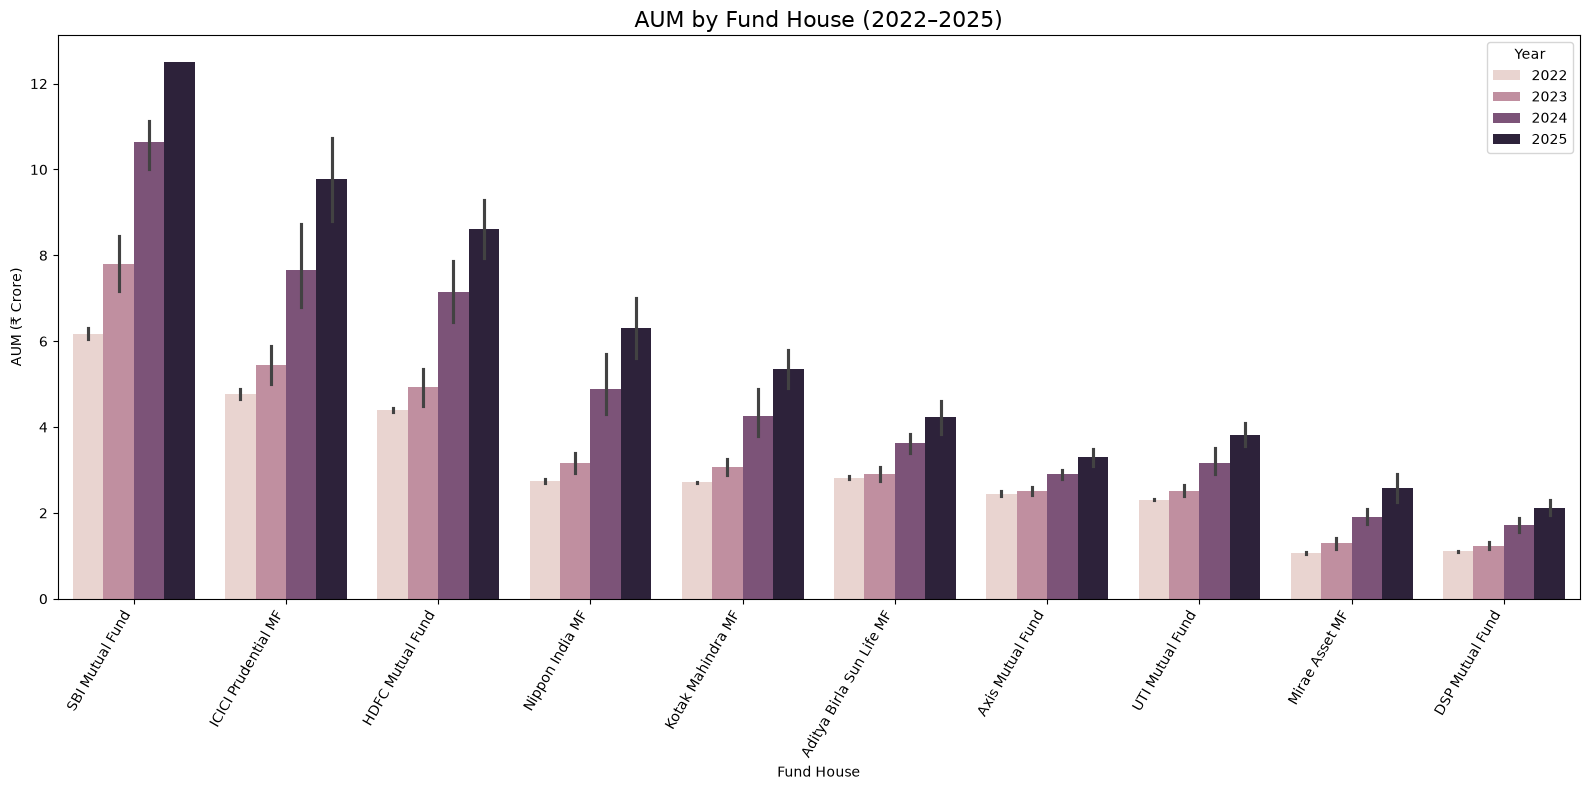


SBI AUM:


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
10,2022-09-30,SBI Mutual Fund,6.30,630000,186,2022
20,2023-03-31,SBI Mutual Fund,7.17,717000,186,2023
30,2023-09-30,SBI Mutual Fund,8.45,845000,186,2023
40,2024-03-31,SBI Mutual Fund,10.00,1000000,186,2024
50,2024-09-30,SBI Mutual Fund,10.80,1080000,186,2024
60,2024-12-31,SBI Mutual Fund,11.14,1114000,186,2024
70,2025-03-31,SBI Mutual Fund,12.50,1250000,186,2025
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186,2025


In [2]:

# DAY 3 - TASK 2: AUM GROWTH BY FUND HOUSE

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load AUM data:
aum_df = pd.read_csv("../Data/Raw/03_aum_by_fund_house.csv")

# Check column names:
print("Columns:", aum_df.columns.tolist())
print("\nFirst 5 rows:")
display(aum_df.head())

# Clean column names:
aum_df.columns = (
    aum_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Convert date to datetime and create year column
aum_df["date"] = pd.to_datetime(aum_df["date"], errors="coerce")
aum_df["year"] = aum_df["date"].dt.year

# Keep only 2022-2025:
aum_2022_2025 = aum_df[
    aum_df["year"].between(2022, 2025)
].copy()

# Find the AUM column automatically:
aum_column = [col for col in aum_2022_2025.columns if "aum" in col][0]

# Find fund-house column automatically:
fund_house_column = [
    col for col in aum_2022_2025.columns
    if "fund" in col and "house" in col
][0]

# Display summary:
print("\nAUM data for 2022-2025:")
display(aum_2022_2025.head())

# Create grouped bar chart:
plt.figure(figsize=(16, 8))

sns.barplot(
    data=aum_2022_2025,
    x=fund_house_column,
    y=aum_column,
    hue="year"
)

plt.title("AUM by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Crore)")
plt.xticks(rotation=60, ha="right")
plt.legend(title="Year")
plt.tight_layout()

# Saving chart to Reports folder:
plt.savefig(
    "../Reports/AUM_Growth_by_Fund_House.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# SBI analysis:
sbi_data = aum_2022_2025[
    aum_2022_2025[fund_house_column]
    .astype(str)
    .str.contains("SBI", case=False, na=False)
]

print("\nSBI AUM:")
display(sbi_data)